# 🛍️ Customer Segmentation Using K-Means + PCA
**Final Project — AI/ML Course**

**Problem Statement:**  
Segment customers into meaningful groups based on their purchasing behavior using unsupervised machine learning.

**Techniques Used:**
- K-Means Clustering
- Elbow Method (to select best K)
- Principal Component Analysis (PCA)
- 2D Cluster Visualization
- Business Interpretation

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load Dataset

We use the **Mall Customer Segmentation** dataset.  
📥 Download from: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python  
Save as `Mall_Customers.csv` in the same folder as this notebook.

**OR** — run the cell below to use our built-in synthetic dataset (no download needed).

In [2]:
import os

# ── Try loading real dataset first ──────────────────────────────────────
if os.path.exists('Mall_Customers.csv'):
    df = pd.read_csv('Mall_Customers.csv')
    df.rename(columns={
        'Annual Income (k$)': 'Annual_Income',
        'Spending Score (1-100)': 'Spending_Score',
        'Age': 'Age'
    }, inplace=True)
    print("✅ Real dataset loaded!")

# ── Else: create synthetic dataset ──────────────────────────────────────
else:
    print("ℹ️  Mall_Customers.csv not found — using synthetic data.")
    np.random.seed(42)
    n = 200

    # Simulate 5 customer segments
    clusters_data = [
        # (age_mean, income_mean, score_mean, size)
        (25, 25,  75, 40),   # Young, low income, high spenders
        (45, 70,  20, 40),   # Middle-aged, high income, low spenders
        (35, 55,  55, 40),   # Average segment
        (55, 30,  30, 40),   # Older, low income, low spenders
        (30, 80,  85, 40),   # Young, high income, high spenders
    ]

    records = []
    for i, (a, inc, sc, sz) in enumerate(clusters_data):
        for _ in range(sz):
            records.append({
                'CustomerID': len(records) + 1,
                'Gender': np.random.choice(['Male', 'Female']),
                'Age': int(np.random.normal(a, 5)),
                'Annual_Income': round(np.random.normal(inc, 8), 1),
                'Spending_Score': int(np.clip(np.random.normal(sc, 10), 1, 100))
            })

    df = pd.DataFrame(records)
    print("✅ Synthetic dataset created!")

print(f"\nShape: {df.shape}")
df.head(10)

ℹ️  Mall_Customers.csv not found — using synthetic data.
✅ Synthetic dataset created!

Shape: (200, 5)


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,22,29.1,79
1,2,Female,31,27.2,85
2,3,Female,22,26.3,77
3,4,Female,25,21.3,70
4,5,Female,25,21.6,69
5,6,Female,24,19.4,53
6,7,Male,17,36.9,74
7,8,Male,26,15.8,78
8,9,Male,14,34.0,82
9,10,Female,19,20.7,74


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
print("=" * 45)
print("DATASET OVERVIEW")
print("=" * 45)
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Statistical Summary ---")
df.describe().round(2)

DATASET OVERVIEW
Rows   : 200
Columns: 5

--- Data Types ---
CustomerID          int64
Gender             object
Age                 int64
Annual_Income     float64
Spending_Score      int64
dtype: object

--- Missing Values ---
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

--- Statistical Summary ---


,CustomerID,Age,Annual_Income,Spending_Score
count,200.00,200.00,200.00,200.00
mean,100.50,37.76,52.31,53.64
std,57.88,11.82,23.32,25.70
min,1.00,14.00,9.50,1.00
25%,50.75,28.00,30.15,29.75
50%,100.50,36.00,56.55,58.50
75%,150.25,47.00,71.10,76.00
max,200.00,66.00,100.60,100.00


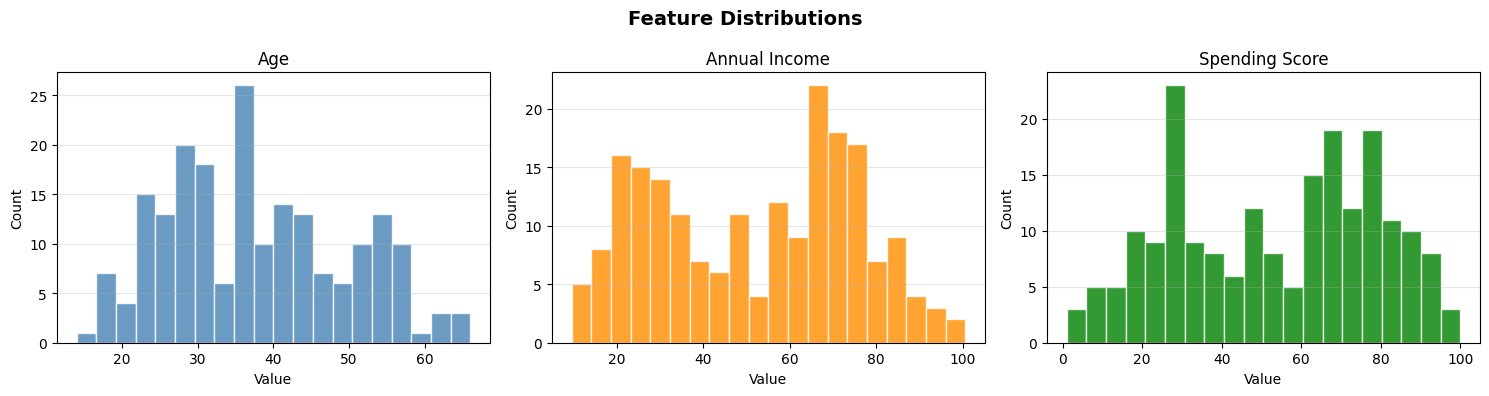

✅ Distribution plots saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes,
                          ['Age', 'Annual_Income', 'Spending_Score'],
                          ['steelblue', 'darkorange', 'green']):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Distribution plots saved.")

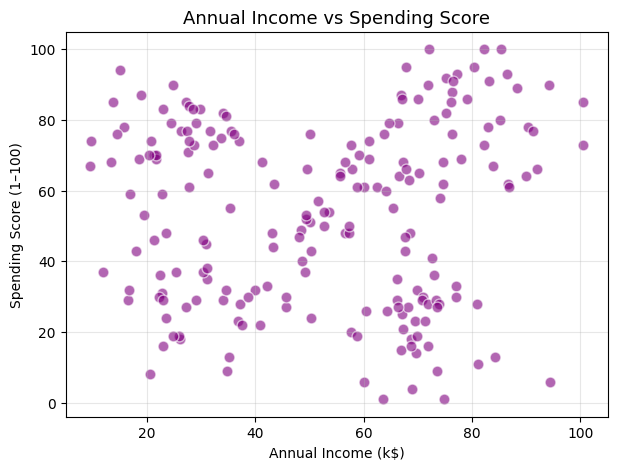

In [5]:
# Scatter: Income vs Spending Score
plt.figure(figsize=(7, 5))
plt.scatter(df['Annual_Income'], df['Spending_Score'],
            alpha=0.6, color='purple', edgecolors='white', s=60)
plt.title('Annual Income vs Spending Score', fontsize=13)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.grid(alpha=0.3)
plt.savefig('scatter_raw.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 4: Handle Missing & Infinite Values

In [6]:
# Select features for clustering
features = ['Age', 'Annual_Income', 'Spending_Score']
X = df[features].copy()

# Replace infinite values with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values with column mean
X.fillna(X.mean(), inplace=True)

print("✅ Missing/Infinite values handled.")
print(f"Missing after cleaning: {X.isnull().sum().sum()}")
X.head()

✅ Missing/Infinite values handled.
Missing after cleaning: 0


,Age,Annual_Income,Spending_Score
0,22,29.1,79
1,31,27.2,85
2,22,26.3,77
3,25,21.3,70
4,25,21.6,69


## Step 5: Feature Scaling

K-Means uses **Euclidean distance** — features must be on the same scale.  
We use `StandardScaler` (mean=0, std=1).

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("✅ Features scaled using StandardScaler.")
print("\nScaled data statistics:")
X_scaled_df.describe().round(3)

✅ Features scaled using StandardScaler.

Scaled data statistics:


,Age,Annual_Income,Spending_Score
count,200.000,200.000,200.000
mean,0.000,0.000,-0.000
std,1.003,1.003,1.003
min,-2.016,-1.841,-2.053
25%,-0.828,-0.953,-0.932
50%,-0.149,0.182,0.190
75%,0.784,0.808,0.872
max,2.396,2.076,1.808


## Step 6: Elbow Method — Find Optimal K

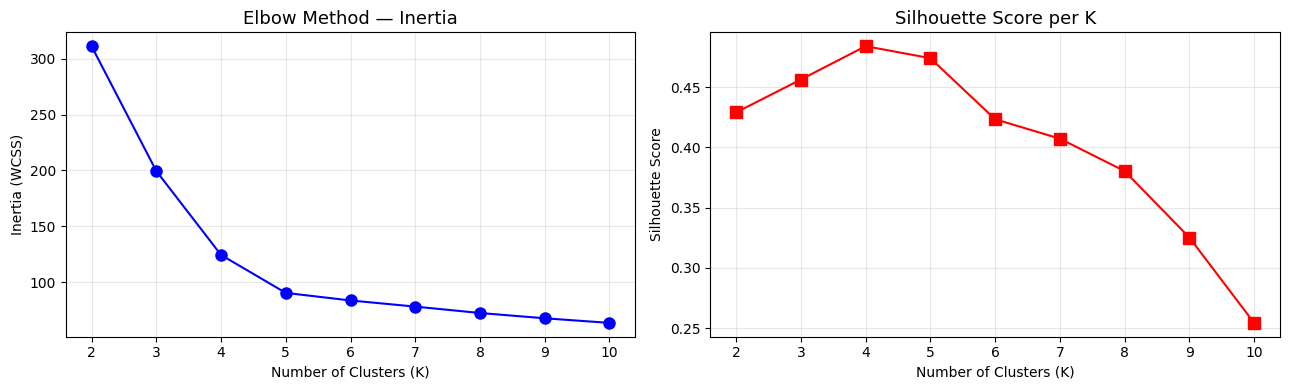


✅ Best K by Silhouette Score: K = 4


In [8]:
inertia_values = []
silhouette_values = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertia_values, 'bo-', markersize=8)
axes[0].set_title('Elbow Method — Inertia', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouette_values, 'rs-', markersize=8)
axes[1].set_title('Silhouette Score per K', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

best_k = K_range[silhouette_values.index(max(silhouette_values))]
print(f"\n✅ Best K by Silhouette Score: K = {best_k}")

## Step 7: Apply K-Means Clustering

In [10]:
OPTIMAL_K = best_k  # Change this if you want to override

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"✅ K-Means applied with K = {OPTIMAL_K}")
print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

✅ K-Means applied with K = 4

Cluster distribution:
Cluster
0    43
1    48
2    70
3    39
Name: count, dtype: int64


## Step 8: Dimensionality Reduction with PCA

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("✅ PCA applied — reduced to 2 components.")
print(f"\nVariance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance retained : {sum(pca.explained_variance_ratio_)*100:.1f}%")

✅ PCA applied — reduced to 2 components.

Variance explained by PC1: 58.4%
Variance explained by PC2: 32.9%
Total variance retained : 91.3%


## Step 9: Visualize Clusters in 2D (PCA Plot)

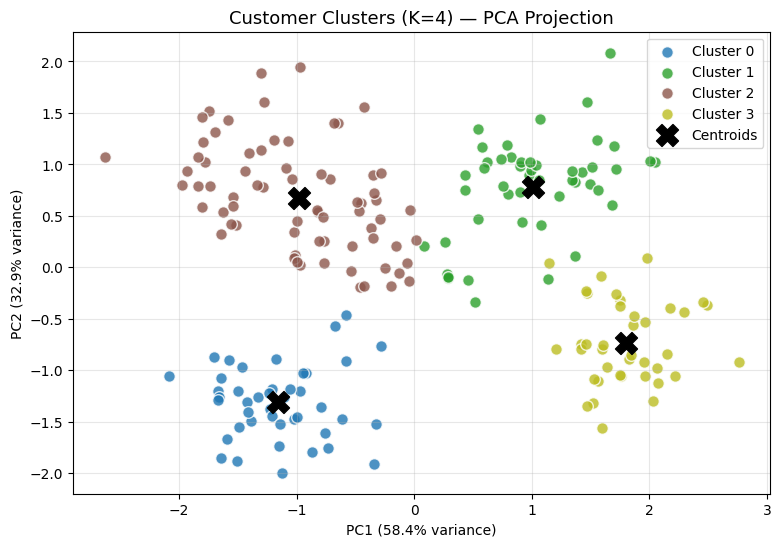

✅ Cluster visualization saved.


In [12]:
colors = cm.tab10(np.linspace(0, 0.8, OPTIMAL_K))

plt.figure(figsize=(9, 6))
for cluster_id in range(OPTIMAL_K):
    mask = df['Cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Cluster {cluster_id}',
        color=colors[cluster_id],
        s=70, alpha=0.8, edgecolors='white'
    )

# Plot centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=250, color='black',
    zorder=5, label='Centroids'
)

plt.title(f'Customer Clusters (K={OPTIMAL_K}) — PCA Projection', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('clusters_pca.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Cluster visualization saved.")

## Step 10: Cluster Analysis & Business Interpretation

In [13]:
print("=" * 55)
print("CLUSTER PROFILE SUMMARY")
print("=" * 55)

cluster_summary = df.groupby('Cluster')[features].mean().round(2)
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index()
print(cluster_summary.to_string())

CLUSTER PROFILE SUMMARY
           Age  Annual_Income  Spending_Score  Count
Cluster                                             
0        25.07          25.55           74.09     43
1        43.48          66.70           26.15     48
2        31.89          71.22           72.87     70
3        55.26          30.16           30.41     39


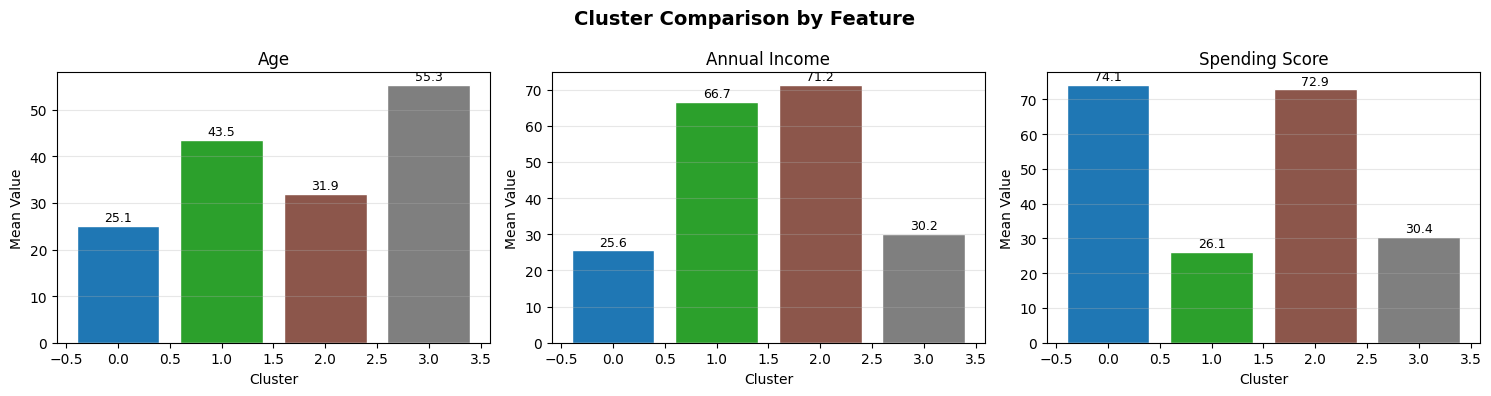

In [14]:
# Visual comparison of clusters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Cluster Comparison by Feature', fontsize=14, fontweight='bold')

palette = [cm.tab10(i / OPTIMAL_K) for i in range(OPTIMAL_K)]

for ax, col in zip(axes, features):
    means = cluster_summary[col]
    bars = ax.bar(means.index, means.values, color=palette, edgecolor='white')
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Mean Value')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('cluster_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
print("=" * 55)
print("BUSINESS INTERPRETATION")
print("=" * 55)

def interpret_cluster(row):
    inc = row['Annual_Income']
    sc  = row['Spending_Score']
    age = row['Age']

    if inc > 60 and sc > 60:
        return "💎 High Value — High Income, High Spenders. Prime targets for premium products."
    elif inc > 60 and sc < 40:
        return "💼 Cautious Affluent — Earn well but spend less. Need trust-building campaigns."
    elif inc < 40 and sc > 60:
        return "🛒 Impulsive Spenders — Low income but high spending. Target with discounts/offers."
    elif inc < 40 and sc < 40:
        return "⚠️  Low Priority — Low income, low spending. Hard to convert."
    else:
        return "📊 Average Segment — Balanced profile. General marketing works here."

for idx, row in cluster_summary.iterrows():
    print(f"\nCluster {idx} (n={int(row['Count'])})")
    print(f"  Age: {row['Age']:.1f}  |  Income: {row['Annual_Income']:.1f}k  |  Score: {row['Spending_Score']:.1f}")
    print(f"  ➤ {interpret_cluster(row)}")

BUSINESS INTERPRETATION

Cluster 0 (n=43)
  Age: 25.1  |  Income: 25.6k  |  Score: 74.1
  ➤ 🛒 Impulsive Spenders — Low income but high spending. Target with discounts/offers.

Cluster 1 (n=48)
  Age: 43.5  |  Income: 66.7k  |  Score: 26.1
  ➤ 💼 Cautious Affluent — Earn well but spend less. Need trust-building campaigns.

Cluster 2 (n=70)
  Age: 31.9  |  Income: 71.2k  |  Score: 72.9
  ➤ 💎 High Value — High Income, High Spenders. Prime targets for premium products.

Cluster 3 (n=39)
  Age: 55.3  |  Income: 30.2k  |  Score: 30.4
  ➤ ⚠️  Low Priority — Low income, low spending. Hard to convert.


## Step 11: Save Results

In [16]:
df.to_csv('customer_segments_output.csv', index=False)
cluster_summary.to_csv('cluster_profiles.csv')

print("✅ Results saved:")
print("  - customer_segments_output.csv  (full data with cluster labels)")
print("  - cluster_profiles.csv          (cluster averages)")
print("  - distributions.png")
print("  - scatter_raw.png")
print("  - elbow_silhouette.png")
print("  - clusters_pca.png")
print("  - cluster_comparison.png")
print("\n🎉 Project Complete!")

✅ Results saved:
  - customer_segments_output.csv  (full data with cluster labels)
  - cluster_profiles.csv          (cluster averages)
  - distributions.png
  - scatter_raw.png
  - elbow_silhouette.png
  - clusters_pca.png
  - cluster_comparison.png

🎉 Project Complete!


---
## Project Summary

| Step | What We Did |
|------|-------------|
| 1 | Imported libraries |
| 2 | Loaded Mall Customers dataset (or synthetic fallback) |
| 3 | Performed EDA — distributions & scatter plots |
| 4 | Handled missing and infinite values |
| 5 | Scaled features with StandardScaler |
| 6 | Found optimal K using Elbow + Silhouette methods |
| 7 | Applied K-Means clustering |
| 8 | Reduced dimensions with PCA |
| 9 | Visualized clusters in 2D |
| 10 | Interpreted clusters for business decisions |
| 11 | Exported results |

**Portfolio Statement:**  
*"Built a complete customer segmentation pipeline using K-Means clustering and PCA dimensionality reduction. Identified distinct customer groups and translated results into actionable business insights."*